1. Read data from google drive with format .gz, then write to google dirve the decompressed .csv files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import pandas as pd
import shutil
import gzip
import os

drive.mount('/content/drive')
project_base = '/content/drive/MyDrive/dba5113_project'
decompress = False

if decompress:
    src = os.path.join(project_base, 'train.gz')
    dst = os.path.join(project_base, 'train.csv')
    with gzip.open(src, 'rb') as f_in:
        with open(dst, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('train.csv done')

    src = os.path.join(project_base, 'test.gz')
    dst = os.path.join(project_base, 'test.csv')
    with gzip.open(src, 'rb') as f_in:
        with open(dst, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('test.csv done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Now the train.csv and test.csv exist, since the research target is to find where is the best place to put advertisement in order to get the best CTR. We would check the distribution of position.

In [ ]:
import polars as pl
import os

project_base = '/content/drive/MyDrive/dba5113_project'

df = pl.scan_csv(
    os.path.join(project_base, 'train.csv'),
    schema_overrides={'id': pl.UInt64}
)

with pl.Config(tbl_cols=-1):
    print(df.head(5).collect())

shape: (5, 24)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ id  ┆ cli ┆ hou ┆ C1  ┆ ban ┆ sit ┆ sit ┆ sit ┆ app ┆ app ┆ app ┆ dev ┆ dev ┆ dev ┆ dev ┆ dev ┆ C14 ┆ C15 ┆ C16 ┆ C17 ┆ C18 ┆ C19 ┆ C20 ┆ C21 │
│ --- ┆ ck  ┆ r   ┆ --- ┆ ner ┆ e_i ┆ e_d ┆ e_c ┆ _id ┆ _do ┆ _ca ┆ ice ┆ ice ┆ ice ┆ ice ┆ ice ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│ u64 ┆ --- ┆ --- ┆ i64 ┆ _po ┆ d   ┆ oma ┆ ate ┆ --- ┆ mai ┆ teg ┆ _id ┆ _ip ┆ _mo ┆ _ty ┆ _co ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
│     ┆ i64 ┆ i64 ┆     ┆ s   ┆ --- ┆ in  ┆ gor ┆ str ┆ n   ┆ ory ┆ --- ┆ --- ┆ del ┆ pe  ┆ nn_ ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     │
│     ┆     ┆     ┆     ┆ --- ┆ str ┆ --- ┆ y   ┆     ┆ --- ┆ --- ┆ str ┆ str ┆ --- ┆ --- ┆ typ ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     │
│     ┆     ┆     ┆     ┆ i64 ┆     ┆ str ┆ --- ┆     ┆ str ┆ str ┆     ┆     ┆ str ┆ i64 ┆ e   ┆     ┆     ┆

3. Check site_id data distribution, keep one website with majority of data for further usage.

In [ ]:
with pl.Config(tbl_cols=-1):
    print(
        df.select(pl.col('site_id').n_unique()).collect()
    )

total = df.select(pl.len()).collect().item()

site_dist = (
    df.group_by('site_id')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(20)
    .collect()
    .with_columns(
        (pl.col('count') / total * 100).alias('pct')
    )
)
print(site_dist)

shape: (1, 1)
┌─────────┐
│ site_id │
│ ---     │
│ u32     │
╞═════════╡
│ 4737    │
└─────────┘
shape: (20, 3)
┌──────────┬──────────┬───────────┐
│ site_id  ┆ count    ┆ pct       │
│ ---      ┆ ---      ┆ ---       │
│ str      ┆ u32      ┆ f64       │
╞══════════╪══════════╪═══════════╡
│ 85f751fd ┆ 14596137 ┆ 36.103166 │
│ 1fbe01fe ┆ 6486150  ┆ 16.043324 │
│ e151e245 ┆ 2637747  ┆ 6.524399  │
│ d9750ee7 ┆ 963745   ┆ 2.383798  │
│ 5b08c53b ┆ 913325   ┆ 2.259086  │
│ …        ┆ …        ┆ …         │
│ 0a742914 ┆ 269725   ┆ 0.667158  │
│ 83a0ad1a ┆ 268735   ┆ 0.664709  │
│ 57fe1b20 ┆ 264952   ┆ 0.655352  │
│ e4d8dd7b ┆ 259347   ┆ 0.641488  │
│ e8f79e60 ┆ 259289   ┆ 0.641345  │
└──────────┴──────────┴───────────┘


4. Let's focus on one single website 85f751fd, which has good amount of data. The same methodology would actually work for any website. We would drop id, site_id, site_domain, site_category before writting them into a smaller data file for further study.

In [ ]:
df = (
    pl.scan_csv(
        os.path.join(project_base, 'train.csv'),
        schema_overrides={'id': pl.UInt64}
    )
    .filter(pl.col('site_id') == '85f751fd')
)

df.sink_csv(os.path.join(project_base, 'train_filtered.csv'))
print("Done — train_filtered.csv written")

Done — train_filtered.csv written


In [ ]:
import polars as pl
import os

project_base = '/content/drive/MyDrive/dba5113_project'

# Scan the full dataset
df_full = pl.scan_csv(
    os.path.join(project_base, 'train_filtered.csv'),
    schema_overrides={'id': pl.UInt64}
)

# Calculate n_unique for every column
cardinality = df_full.select([
    pl.all().n_unique()
]).collect()

with pl.Config(tbl_cols=-1):
    display(cardinality)

id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
14596137,2,240,7,6,1,1,1,8551,559,36,1737392,2724972,6918,4,4,2252,8,9,369,4,63,170,55


5. Write to new csv files, drop the columns after first study.

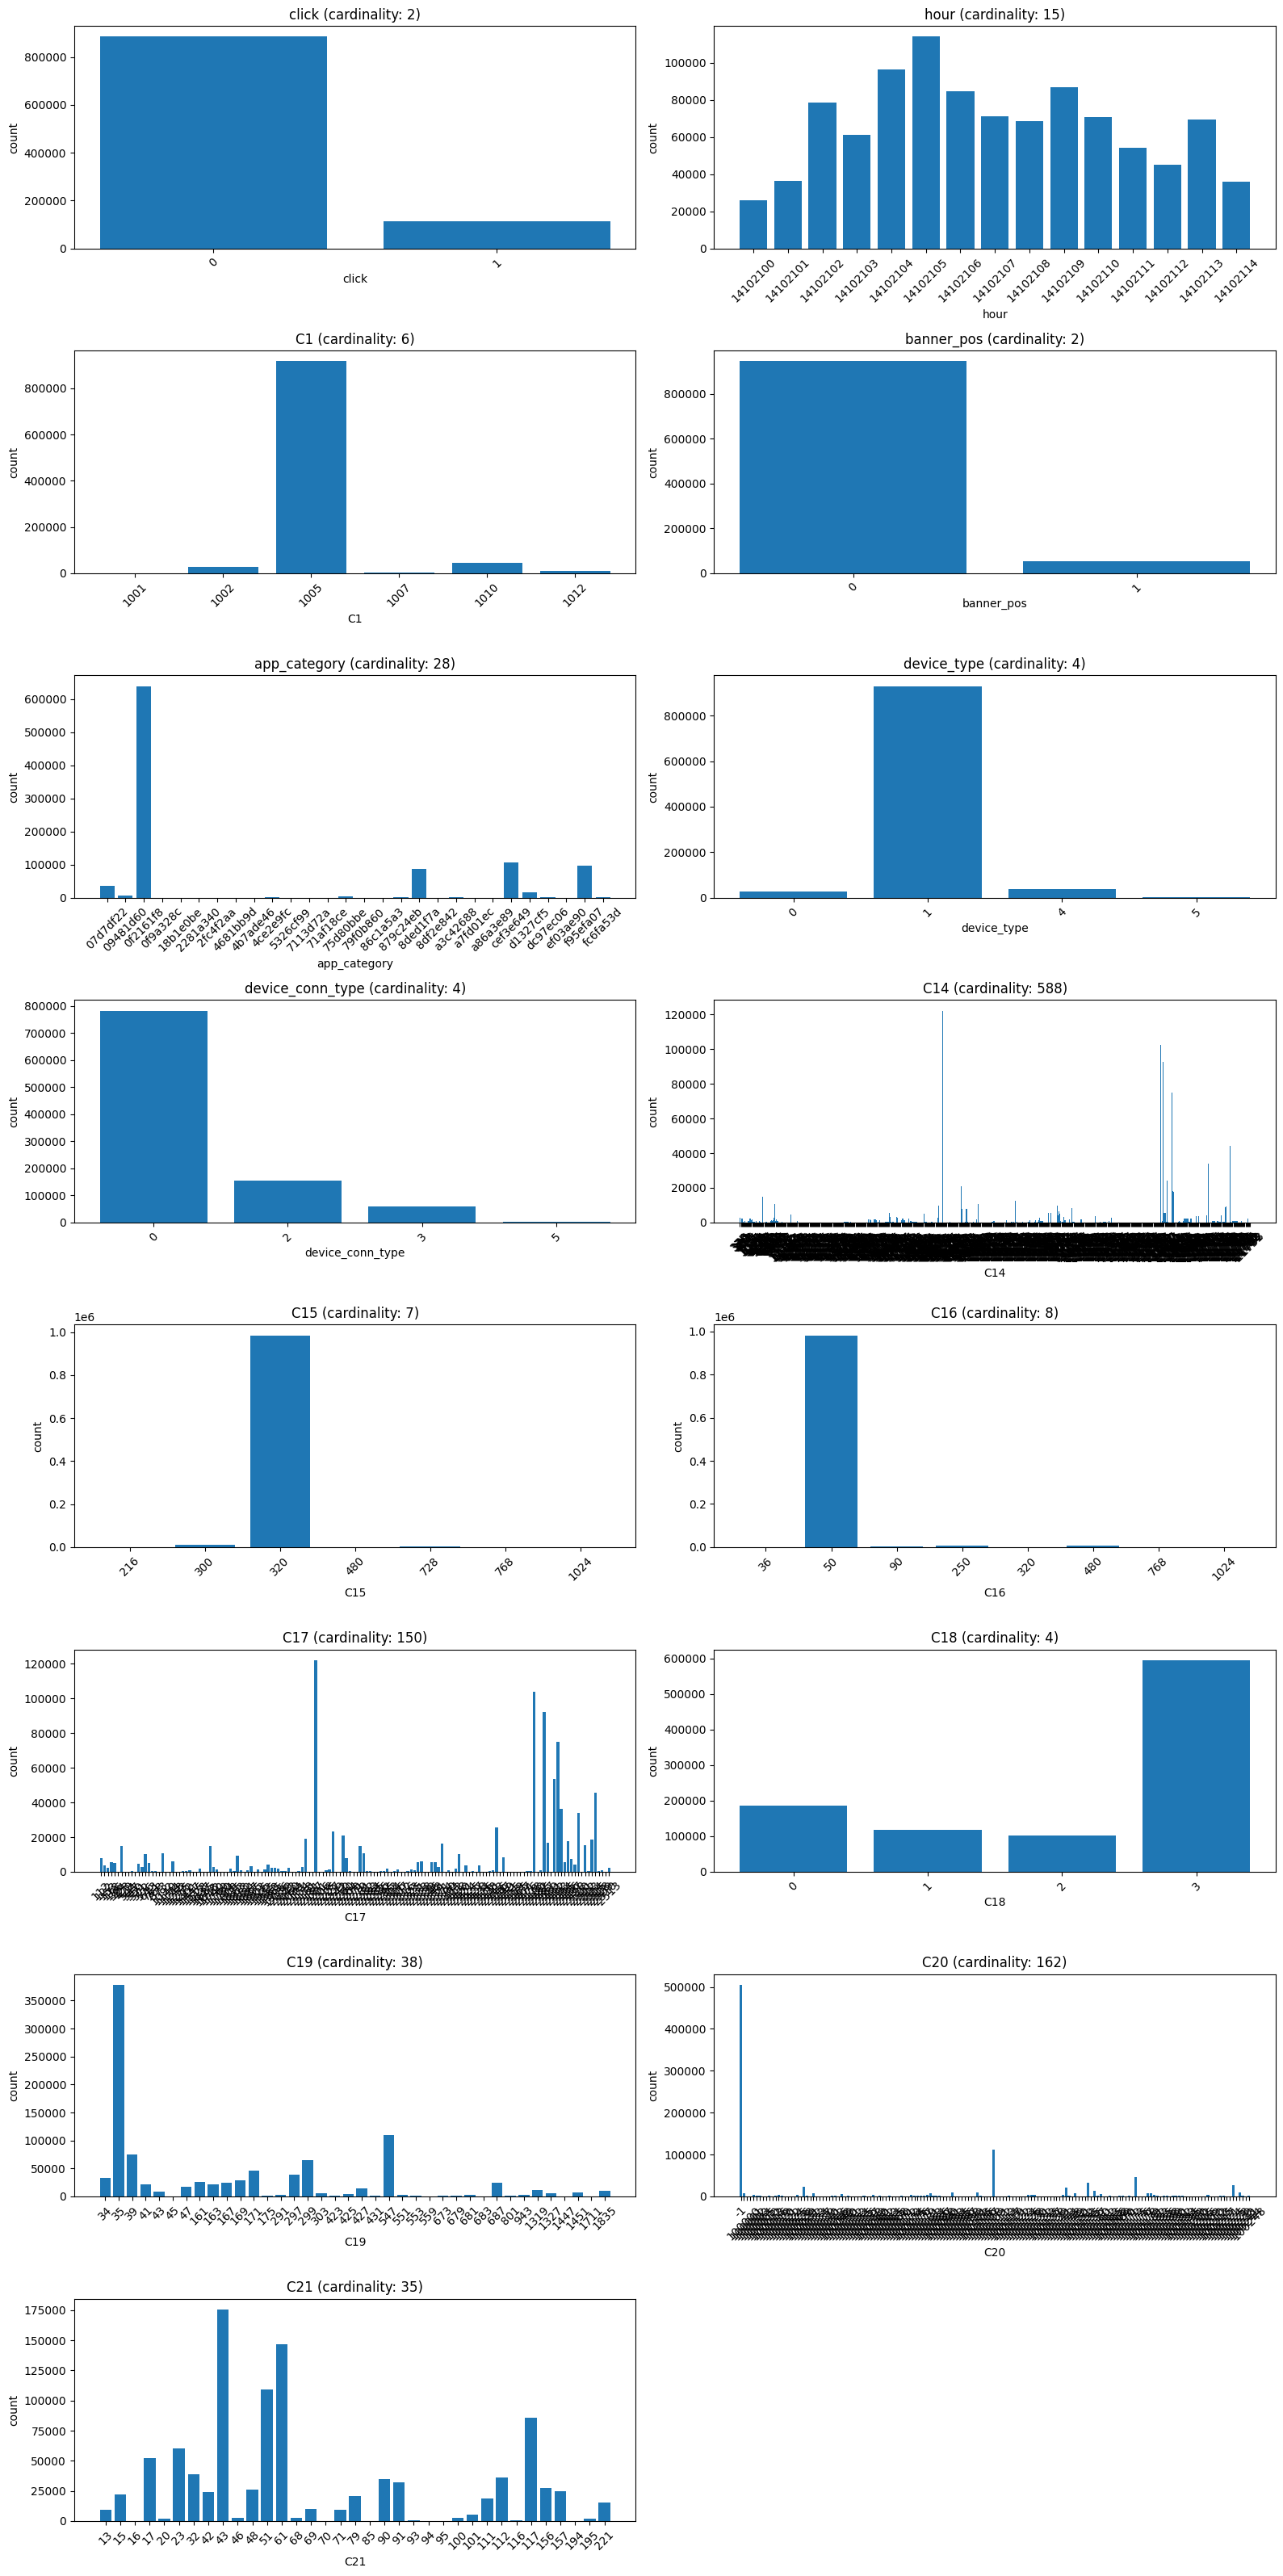

C15: top value concentration = 96.53%
C16: top value concentration = 98.10%
C1: top value concentration = 91.58%
C14                 0.022649
C17                 0.021063
C21                 0.017707
C19                 0.016234
C18                 0.006950
C20                 0.006066
app_category        0.004362
C1                  0.003312
device_type         0.002791
device_conn_type    0.002225
hour                0.002175
C15                 0.000579
C16                 0.000496
banner_pos          0.000285
dtype: float64
Done — train_clean.csv written


In [ ]:
import polars as pl
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols_to_drop = [
    'id', 'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain',
    'device_id', 'device_ip', 'device_model'
]

df_temp = df_full.drop(cols_to_drop).filter(pl.col('banner_pos').is_in([0, 1]))

# Sample for plotting only
df_sample = df_temp.head(1_000_000).collect()

cols = df_sample.columns
n_cols = len(cols)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    counts = df_sample[col].value_counts().sort(col)
    axes[i].bar(counts[col].cast(pl.Utf8).to_list(), counts['count'].to_list())
    axes[i].set_title(f'{col} (cardinality: {df_sample[col].n_unique()})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplot if odd number of cols
if n_cols % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# By Observing the distribution, we have seen C15 and C16 are very concentrated in 1 or 2 values,
# let's check the feature variance to make sure it is good to keep them or just drop
for col in ['C15', 'C16', 'C1']:
    total = df_temp.select(pl.len()).collect().item()
    top = df_temp.select(
        pl.col(col).value_counts(sort=True)
    ).collect().head(1)
    top_count = top[col][0]['count']
    print(f"{col}: top value concentration = {top_count/total*100:.2f}%")

sample = df_sample.to_pandas()

# Encode string columns

le = LabelEncoder()
sample['app_category'] = le.fit_transform(sample['app_category'].astype(str))

X = sample.drop(columns=['click'])
y = sample['click']

mi = mutual_info_classif(X, y, discrete_features=True)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

# Write full data
df_temp.drop(['C15','C16']).sink_csv(os.path.join(project_base, 'train_clean.csv'))
print("Done — train_clean.csv written")

In [ ]:
!nvidia-smi

Thu Apr  9 07:23:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             35W /   70W |    1111MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install cuml-cu12 --quiet

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm

print("Loading data from Google Drive...")
df = pd.read_csv('/content/drive/MyDrive/dba5113_project/train_clean.csv')

df = df[df['banner_pos'].isin([0, 1])]
print(f"Remaining rows for study: {len(df)}")

df['day'] = (df['hour'] // 100) % 100

print(f"Total rows: {len(df)}")
print(f"Days present: {df['day'].unique()}")

train_mask = df['day'] < 30
val_mask = df['day'] == 30

Loading data from Google Drive...
Remaining rows for study: 14545957
Total rows: 14545957
Days present: [21 22 23 24 25 26 27 28 29 30]


In [ ]:
df.columns.tolist()

['click',
 'hour',
 'C1',
 'banner_pos',
 'app_category',
 'device_type',
 'device_conn_type',
 'C14',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'day']

In [ ]:
# ==========================================
# XGBoost
# ==========================================
def preprocess_selected(df):
    processed = df.copy()
    processed['hour_of_day'] = processed['hour'].apply(lambda x: int(str(x)[-2:]))

    cat_features = ['C1','banner_pos','app_category','device_type','device_conn_type','C14','C17','C18','C19','C20', 'C21'
    ]

    for col in cat_features:
        processed[col] = processed[col].astype('category').cat.codes

    features = ['hour_of_day'] + cat_features
    return processed[features], processed['click']

X_all, y_all = preprocess_selected(df)
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]

print(f"Training on Days 21-29: {len(X_train)} rows")
print(f"Validating on Day 30:   {len(X_val)} rows")
print(f"Selected features ({len(X_all.columns)}): {list(X_all.columns)}")

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

Training on Days 21-29: 12595567 rows
Validating on Day 30:   1950390 rows
Selected features (12): ['hour_of_day', 'C1', 'banner_pos', 'app_category', 'device_type', 'device_conn_type', 'C14', 'C17', 'C18', 'C19', 'C20', 'C21']


In [ ]:
# ==========================================
# XGBoost
# ==========================================
def preprocess_selected(df):
    processed = df.copy()
    processed['hour_of_day'] = processed['hour'].apply(lambda x: int(str(x)[-2:]))

    cat_features = ['C1','banner_pos','app_category','device_type','device_conn_type','C14','C17','C18','C19','C20', 'C21'
    ]

    for col in cat_features:
        processed[col] = processed[col].astype('category').cat.codes

    features = ['hour_of_day'] + cat_features
    return processed[features], processed['click']

X_all, y_all = preprocess_selected(df)
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]

print(f"Training on Days 21-29: {len(X_train)} rows")
print(f"Validating on Day 30:   {len(X_val)} rows")
print(f"Selected features ({len(X_all.columns)}): {list(X_all.columns)}")

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

num_neg = len(y_train[y_train == 0])
num_pos = len(y_train[y_train == 1])
ratio = num_neg / num_pos

print(f"Negative/Positive ratio: {ratio:.2f}")
# ==========================================
# PERFORMANCE MONITOR
# ==========================================
class PerformanceMonitor(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds, depth, metrics_path='depth_search_results_xgb.csv'):
        self.metrics_path = metrics_path
        self.depth = depth
        self.best_logloss = float('inf')
        self.pbar = tqdm(total=total_rounds, desc=f"Depth {depth}")

        if os.path.exists(self.metrics_path):
            self.master_logs = pd.read_csv(self.metrics_path, index_col=0)
        else:
            self.master_logs = pd.DataFrame()

    def after_iteration(self, model, epoch, evals_log):
        train_loss = evals_log['train']['logloss'][-1]
        val_loss = evals_log['eval']['logloss'][-1]

        self.master_logs.loc[epoch, f'depth_{self.depth}_train'] = train_loss
        self.master_logs.loc[epoch, f'depth_{self.depth}_val'] = val_loss
        self.master_logs.to_csv(self.metrics_path)

        if val_loss < self.best_logloss:
            self.best_logloss = val_loss
            model.save_model(f'model_weights_xgb_depth_{self.depth}.json')

        self.pbar.set_postfix_str(f"Val: {val_loss:.4f} | Best: {self.best_logloss:.4f}")
        self.pbar.update(1)
        return False

    def after_training(self, model):
        self.pbar.close()
        return model

# ==========================================
# DEPTH SEARCH
# ==========================================
NUM_ROUNDS = 5000
DEPTHS_TO_TEST = [6, 8, 10]
xgb_depth_comparison = {}

if os.path.exists('depth_search_results_xgb.csv'):
    os.remove('depth_search_results_xgb.csv')

for d in DEPTHS_TO_TEST:
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': d,
        'learning_rate': 0.05,
        'device': 'cuda',
        'random_state': 1
    }

    monitor = PerformanceMonitor(total_rounds=NUM_ROUNDS, depth=d)

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=NUM_ROUNDS,
        evals=[(dtrain, 'train'), (dval, 'eval')],
        callbacks=[monitor],
        verbose_eval=False
    )

    xgb_depth_comparison[f"Depth {d}"] = monitor.best_logloss

# ==========================================
# RESULTS — XGBoost
# ==========================================
print("\n" + "=" * 50)
print("XGBoost SEARCH COMPLETE")
print("=" * 50)
for config, loss in xgb_depth_comparison.items():
    print(f"  {config}: Val LogLoss = {loss:.6f}")
print("=" * 50)

Training on Days 21-29: 12595567 rows
Validating on Day 30:   1950390 rows
Selected features (12): ['hour_of_day', 'C1', 'banner_pos', 'app_category', 'device_type', 'device_conn_type', 'C14', 'C17', 'C18', 'C19', 'C20', 'C21']
Negative/Positive ratio: 7.58


Depth 6:   0%|          | 0/5000 [00:00<?, ?it/s]

Depth 8:   0%|          | 0/5000 [00:00<?, ?it/s]

Depth 10:   0%|          | 0/5000 [00:00<?, ?it/s]


XGBoost SEARCH COMPLETE
  Depth 6: Val LogLoss = 0.361505
  Depth 8: Val LogLoss = 0.367517
  Depth 10: Val LogLoss = 0.371475


In [21]:
# ==========================================
# ROUND 2 — Random Forest ORACLE (SAME FEATURES, GPU)
# Uses X_train, y_train, X_val, y_val from the XGB cell above
# ==========================================
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.metrics import log_loss
import joblib
import cudf

# Convert to cuDF for GPU acceleration
X_train_cu = cudf.DataFrame(X_train.astype(np.float32))
y_train_cu = cudf.Series(y_train.values.astype(np.int32))
X_val_cu = cudf.DataFrame(X_val.astype(np.float32))

# ==========================================
# N_ESTIMATORS SEARCH — Random Forest (GPU)
# RF uses deep/unlimited trees by default (regularized via bagging)
# The main knob is number of trees
# ==========================================
N_ESTIMATORS_TO_TEST = [100, 300, 500]
RF_PARAMS = {
    'max_depth': 30,
    'max_features': 'sqrt',
    'random_state': 1,
}
rf_comparison = {}

metrics_path_rf = 'search_results_rf.csv'
if os.path.exists(metrics_path_rf):
    os.remove(metrics_path_rf)

rf_logs = pd.DataFrame()

for n_est in N_ESTIMATORS_TO_TEST:
    print(f"\nTraining RF (n_estimators={n_est})")

    rf = cuRF(n_estimators=n_est, output_type='numpy', **RF_PARAMS)
    rf.fit(X_train_cu, y_train_cu)

    train_proba = rf.predict_proba(X_train_cu)[:, 1]
    val_proba = rf.predict_proba(X_val_cu)[:, 1]

    train_loss = log_loss(y_train, train_proba)
    val_loss = log_loss(y_val, val_proba)

    rf_comparison[f"n_est={n_est}"] = val_loss
    rf_logs.loc[n_est, 'train_logloss'] = train_loss
    rf_logs.loc[n_est, 'val_logloss'] = val_loss
    rf_logs.to_csv(metrics_path_rf)

    joblib.dump(rf, f'model_weights_rf_n{n_est}.pkl')

    print(f"  RF n_est={n_est}: Train LogLoss = {train_loss:.6f} | Val LogLoss = {val_loss:.6f}")

# ==========================================
# RESULTS — Random Forest
# ==========================================
print("\n" + "=" * 50)
print("RANDOM FOREST SEARCH COMPLETE")
print("=" * 50)
for config, loss in rf_comparison.items():
    print(f"  {config}: Val LogLoss = {loss:.6f}")
print("=" * 50)


Training RF (n_estimators=100)
  RF n_est=100: Train LogLoss = 0.315845 | Val LogLoss = 0.367809

Training RF (n_estimators=300)
  RF n_est=300: Train LogLoss = 0.315851 | Val LogLoss = 0.366316

Training RF (n_estimators=500)
  RF n_est=500: Train LogLoss = 0.315841 | Val LogLoss = 0.366770

RANDOM FOREST SEARCH COMPLETE
  n_est=100: Val LogLoss = 0.367809
  n_est=300: Val LogLoss = 0.366316
  n_est=500: Val LogLoss = 0.366770


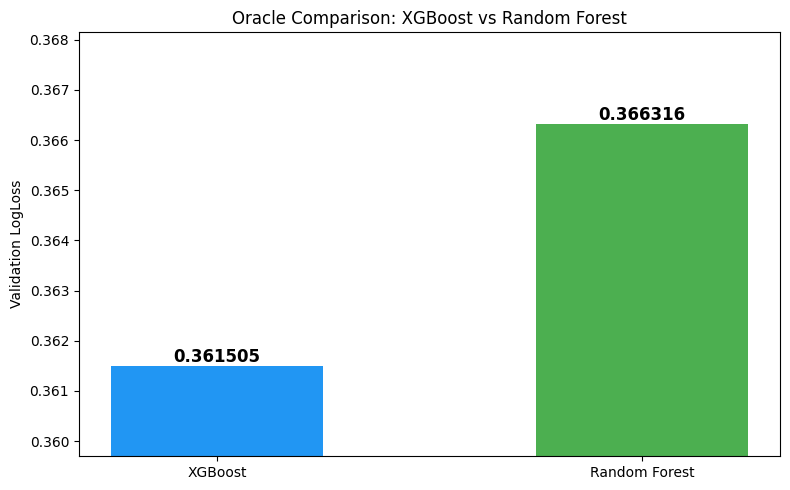

ORACLE COMPARISON: XGBoost vs Random Forest
  Best XGBoost:       0.361505 (Depth 6)
  Best Random Forest: 0.366316 (n_est=300)
  Difference:         0.004811
  → XGBoost wins as oracle


In [22]:
# ==========================================
# ORACLE COMPARISON: XGBoost vs Random Forest
# ==========================================
import matplotlib.pyplot as plt

best_xgb = min(xgb_depth_comparison.values())
best_rf = min(rf_comparison.values())
best_xgb_config = min(xgb_depth_comparison, key=xgb_depth_comparison.get)
best_rf_config = min(rf_comparison, key=rf_comparison.get)

# Bar plot
models = ['XGBoost', 'Random Forest']
losses = [best_xgb, best_rf]
colors = ['#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, losses, color=colors, width=0.5)

for bar, loss in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{loss:.6f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Validation LogLoss')
ax.set_title('Oracle Comparison: XGBoost vs Random Forest')
y_min = min(losses) * 0.995
y_max = max(losses) * 1.005
ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.savefig('oracle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("=" * 50)
print("ORACLE COMPARISON: XGBoost vs Random Forest")
print("=" * 50)
print(f"  Best XGBoost:       {best_xgb:.6f} ({best_xgb_config})")
print(f"  Best Random Forest: {best_rf:.6f} ({best_rf_config})")
print(f"  Difference:         {abs(best_rf - best_xgb):.6f}")
if best_xgb < best_rf:
    print("  → XGBoost wins as oracle")
else:
    print("  → Random Forest wins as oracle")
print("=" * 50)

In [23]:
df.nunique().sort_values()

,0
click,2
banner_pos,2
device_conn_type,4
device_type,4
C18,4
C1,6
day,10
app_category,35
C21,55
C19,63


Sampling 1,000,000 rows from training set (days 21-29) for LRT...
One-hot encoding 9 features...
Encoded dimension: 340

Fitting full model (all features)...
Full model negative log-likelihood: 330483.01

Running LRT for each feature (parallel, 8 cores)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:    9.2s remaining:   32.0s
[Parallel(n_jobs=-1)]: Done   3 out of   9 | elapsed:    9.2s remaining:   18.4s
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:    9.2s remaining:   11.6s
[Parallel(n_jobs=-1)]: Done   5 out of   9 | elapsed:   10.0s remaining:    8.0s
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:   10.2s remaining:    5.1s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:   10.2s remaining:    2.9s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:   12.2s finished



LIKELIHOOD RATIO TEST — FEATURE IMPORTANCE FOR LinUCB
         feature  cardinality  lr_statistic       p_value  signal_per_dim significance
device_conn_type            4   2053.784498  0.000000e+00      513.446125          ***
             C18            4    734.523925 1.164966e-157      183.630981          ***
    app_category           28   4474.831694  0.000000e+00      159.815418          ***
             C21           50   4609.962072  0.000000e+00       92.199241          ***
             C19           58   2572.309842  0.000000e+00       44.350170          ***
              C1            6    198.311508  4.340785e-40       33.051918          ***
     device_type            4     89.345873  1.813214e-18       22.336468          ***
             C20          162   3151.495318  0.000000e+00       19.453675          ***
     hour_of_day           24    448.138655  9.177738e-80       18.672444          ***
*** p<0.001  ** p<0.01  * p<0.05  ns = not significant


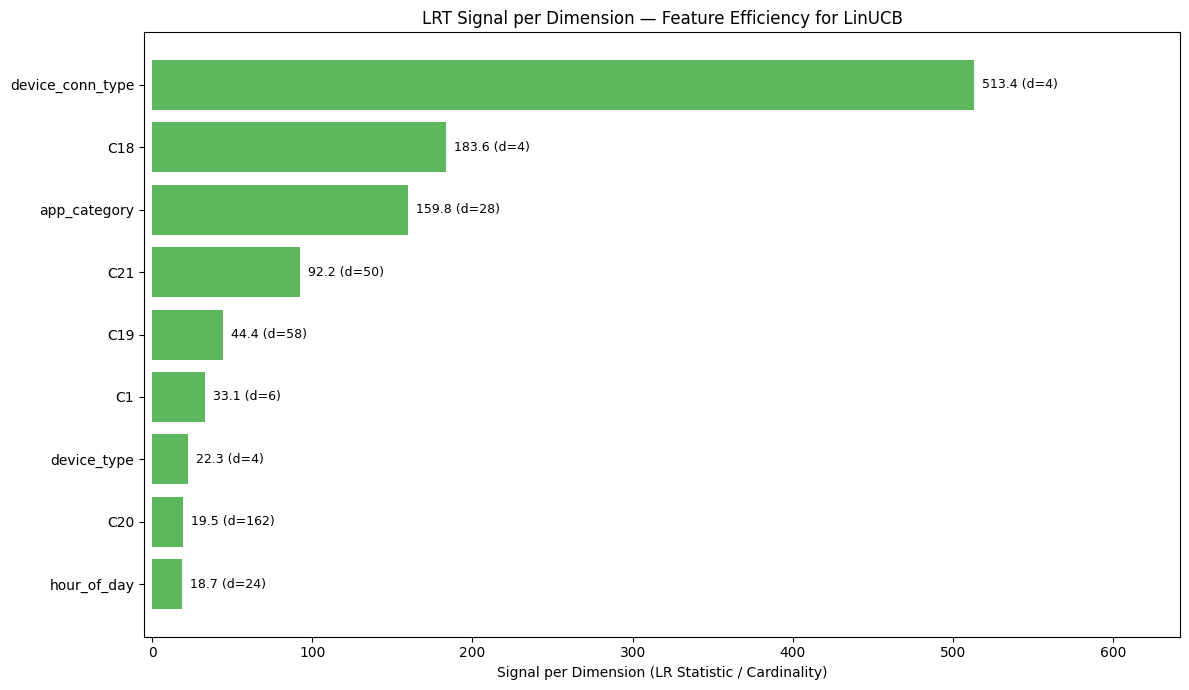

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ==========================================
# LIKELIHOOD RATIO TEST — FEATURE SELECTION FOR LinUCB
# Features with cardinality <= 200
# ==========================================

linucb_features = [
    'device_conn_type', 'C18', 'device_type', 'C1', 'app_category',
    'C21', 'C19','C20'
]

SAMPLE_SIZE = 1_000_000
print(f"Sampling {SAMPLE_SIZE:,} rows from training set (days 21-29) for LRT...")
sample = df[train_mask].sample(SAMPLE_SIZE, random_state=1).copy()
sample['hour_of_day'] = sample['hour'].apply(lambda x: int(str(x)[-2:]))
y_sample = sample['click'].values

all_features = ['hour_of_day'] + linucb_features
cardinality_map = {col: sample[col].nunique() for col in all_features}

X_sample = sample[all_features].astype(str)

print(f"One-hot encoding {len(all_features)} features...")
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_encoded = ohe.fit_transform(X_sample).astype(np.float32)
feature_names = list(ohe.get_feature_names_out(all_features))
print(f"Encoded dimension: {X_encoded.shape[1]}")

def fit_and_ll(X, y):
    model = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=1)
    model.fit(X, y)
    proba = model.predict_proba(X)
    ll = -np.sum(np.log(np.clip(proba[np.arange(len(y)), y], 1e-15, 1.0)))
    return ll

# Step 1: Fit the full model
print("\nFitting full model (all features)...")
full_ll = fit_and_ll(X_encoded, y_sample)
print(f"Full model negative log-likelihood: {full_ll:.2f}")

# Step 2: For each feature, fit reduced model and compute LR statistic
PARALLEL = True

def test_feature(feat):
    col_mask = [not fn.startswith(feat + '_') for fn in feature_names]
    X_reduced = X_encoded[:, col_mask]
    df_lost = cardinality_map[feat]
    reduced_ll = fit_and_ll(X_reduced, y_sample)
    lr_stat = 2 * (reduced_ll - full_ll)
    p_value = chi2.sf(lr_stat, df=df_lost)
    return {'feature': feat, 'cardinality': df_lost, 'lr_statistic': lr_stat, 'p_value': p_value}

if PARALLEL:
    from joblib import Parallel, delayed
    print(f"\nRunning LRT for each feature (parallel, {os.cpu_count()} cores)...")
    lrt_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(test_feature)(feat) for feat in all_features
    )
else:
    print("\nRunning LRT for each feature (sequential)...")
    lrt_results = []
    for feat in all_features:
        print(f"  Testing without {feat} (dropping {cardinality_map[feat]} dummy columns)...")
        lrt_results.append(test_feature(feat))

lrt_df = pd.DataFrame(lrt_results)
lrt_df['signal_per_dim'] = lrt_df['lr_statistic'] / lrt_df['cardinality']

def significance_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

lrt_df['significance'] = lrt_df['p_value'].apply(significance_stars)
lrt_df = lrt_df.sort_values('signal_per_dim', ascending=True).reset_index(drop=True)

print("\n" + "=" * 80)
print("LIKELIHOOD RATIO TEST — FEATURE IMPORTANCE FOR LinUCB")
print("=" * 80)
print(lrt_df.sort_values('signal_per_dim', ascending=False).to_string(index=False))
print("=" * 80)
print("*** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

# Signal per dimension bar chart
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in lrt_df['signal_per_dim']]
ax.barh(lrt_df['feature'], lrt_df['signal_per_dim'], color=colors)
for i, row in lrt_df.iterrows():
    val = row['signal_per_dim']
    if val < 0:
        ax.text(0.5, i, f'  {val:.1f} (d={row["cardinality"]})',
                ha='left', va='center', fontsize=9)
    else:
        ax.text(val, i, f'  {val:.1f} (d={row["cardinality"]})',
                ha='left', va='center', fontsize=9)
max_val = lrt_df['signal_per_dim'].max()
ax.set_xlim(left=min(0, lrt_df['signal_per_dim'].min()) - 5, right=max_val * 1.25)
ax.set_xlabel('Signal per Dimension (LR Statistic / Cardinality)')
ax.set_title('LRT Signal per Dimension — Feature Efficiency for LinUCB')
plt.tight_layout()
plt.savefig('lrt_signal_per_dim.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
mab_eval_df = df[val_mask].sample(n=1200000, random_state=1).reset_index(drop=True)

In [26]:
mab_eval_df.banner_pos.value_counts()

,count
banner_pos,
0,1145757
1,54243


Successfully loaded Oracle: model_weights_xgb_depth_6.json
Encoding features for Oracle benchmark...
Generating Oracle 'What-If' probabilities...
MAB Linear Feature Space: 274 dimensions
Step 1: Evaluating different Alphas for LinUCB...


Alpha 0.1:   0%|          | 0/1200000 [00:00<?, ?it/s]

Alpha 0.5:   0%|          | 0/1200000 [00:00<?, ?it/s]

Alpha 1.0:   0%|          | 0/1200000 [00:00<?, ?it/s]

Alpha 1.5:   0%|          | 0/1200000 [00:00<?, ?it/s]


Alpha           | Final CTR  | Avg Regret  
---------------------------------------------
0.1             | 0.17474 | 0.00265
0.5             | 0.17829 | 0.00549
1.0             | 0.17326 | 0.00952
1.5             | 0.17007 | 0.01079
Best Alpha found: 0.5

Step 2: Evaluating Baselines and Final Comparison...


Eps-Greedy:   0%|          | 0/1200000 [00:00<?, ?it/s]

UCB1:   0%|          | 0/1200000 [00:00<?, ?it/s]


Algorithm       | Final CTR  | Avg Regret  
---------------------------------------------
Eps-Greedy      | 0.12994 | 0.00253
UCB1            | 0.12877 | 0.00445
LinUCB (a=0.5)  | 0.17829 | 0.00549

Algorithm          | Match Rate | Selections (0/1)     | Matches (0/1)   | CTR
-------------------------------------------------------------------------------------
Eps-Greedy         |    93.14% | 1169112/30888        | 1116299/1430    | 0.12994
UCB1               |    39.14% | 456805/743195        | 436127/33565    | 0.12877
LinUCB (a=0.5)     |    15.94% | 228108/971892        | 182570/8705     | 0.17829


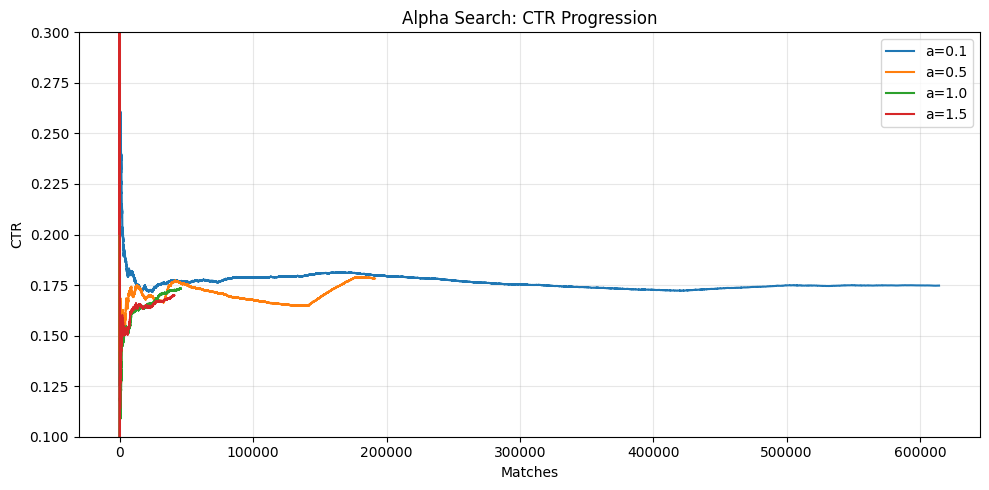

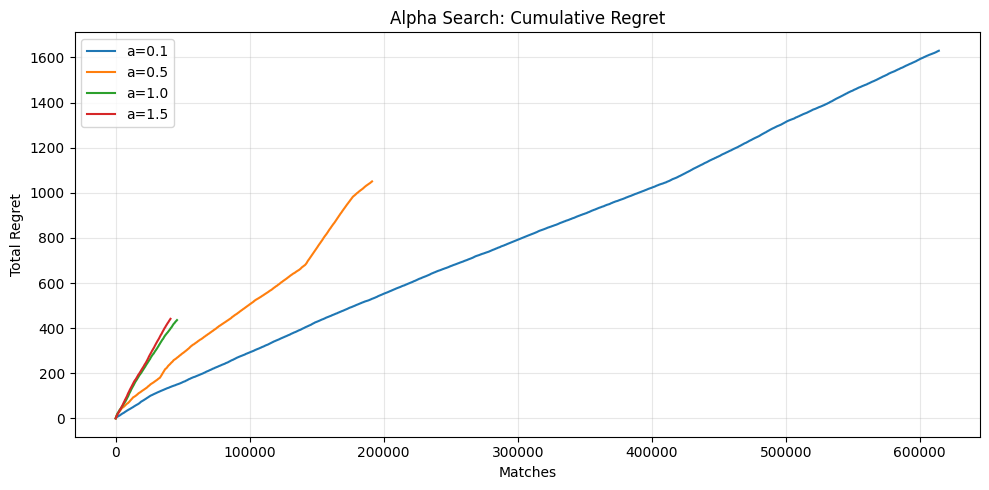

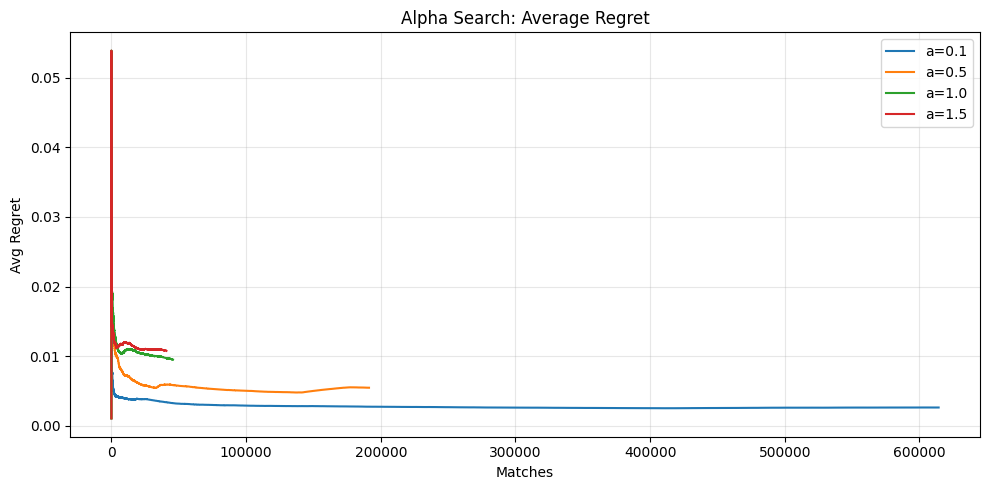

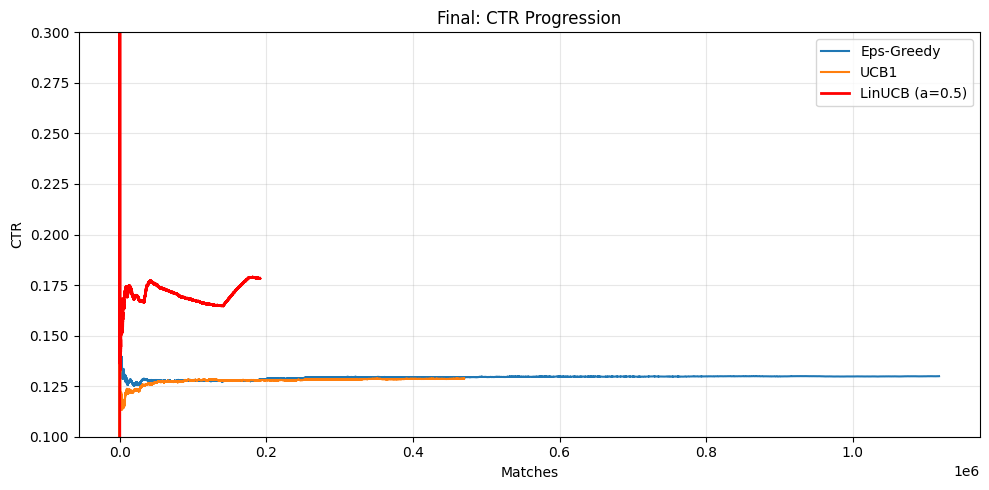

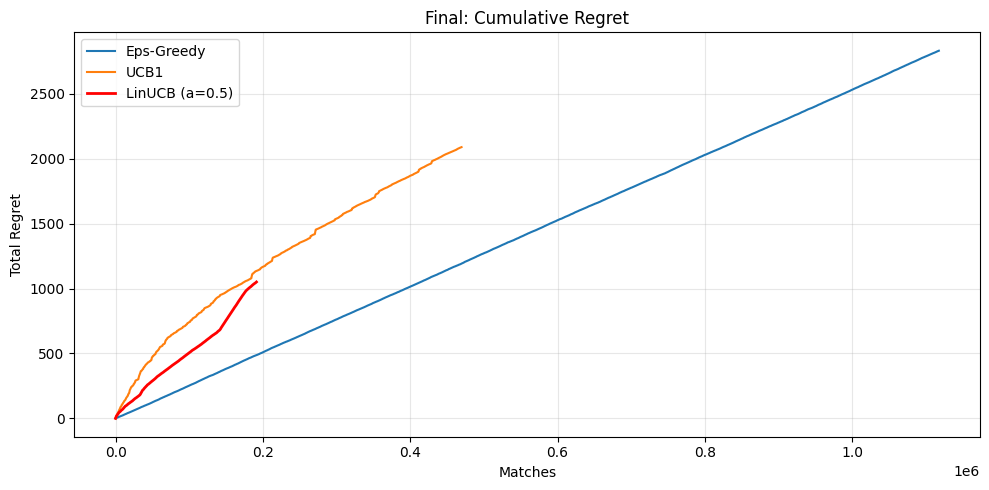

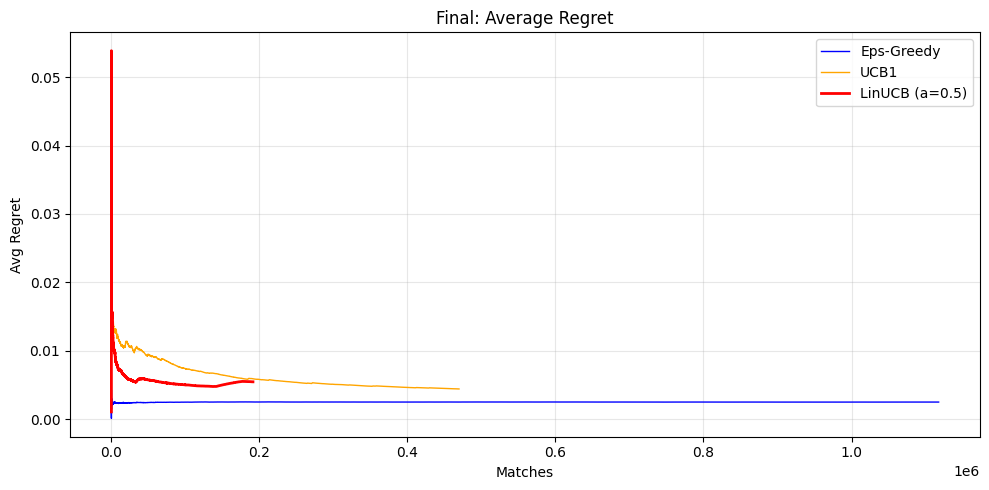

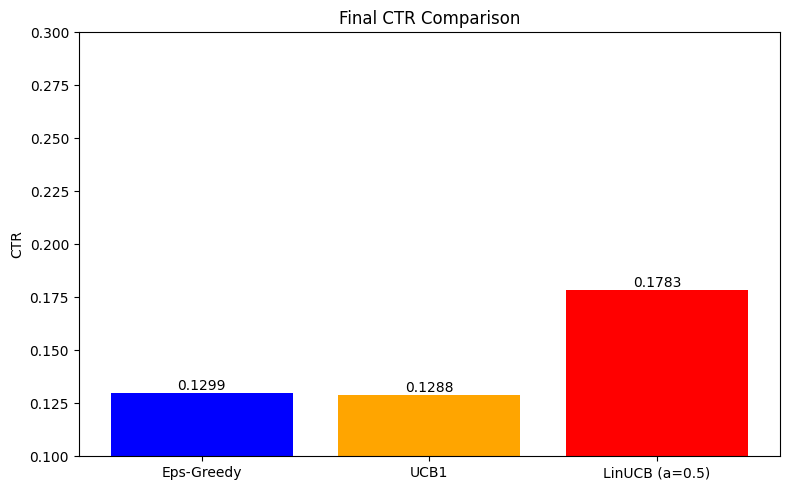

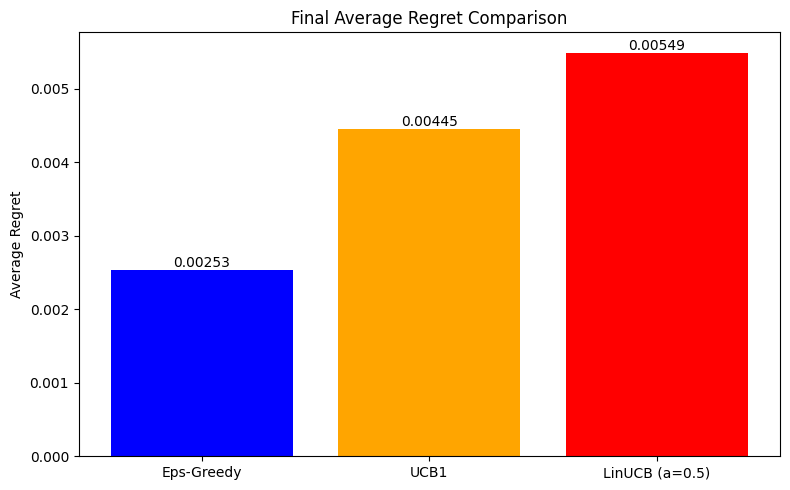

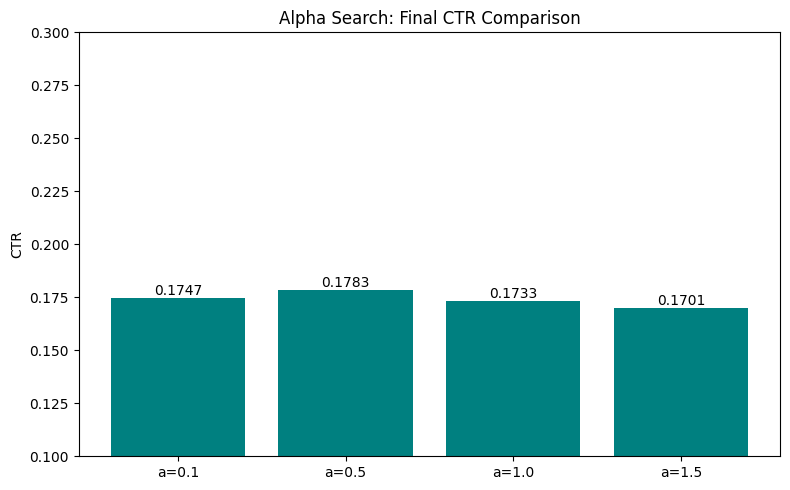

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from tqdm.auto import tqdm
import os

# ==========================================
# 0. CONFIGURATION & ORACLE LOADING
# ==========================================
ORACLE_PATH = 'model_weights_xgb_depth_6.json'
mab_df = mab_eval_df.copy()

mab_df = mab_df[mab_df['banner_pos'].isin([0, 1])].reset_index(drop=True)

if os.path.exists(ORACLE_PATH):
    oracle_model = xgb.Booster()
    oracle_model.load_model(ORACLE_PATH)
    print(f"Successfully loaded Oracle: {ORACLE_PATH}")
else:
    raise FileNotFoundError(f"Oracle weight file not found at {ORACLE_PATH}.")

# ==========================================
# 1. DATA PREPARATION (Oracle vs MAB)
# ==========================================
mab_df['Reward'] = mab_df['click']
mab_df['hour_of_day'] = mab_df['hour'].apply(lambda x: int(str(x)[-2:]))

arm_names = [0, 1]
k_arms = len(arm_names)
mab_df['arm'] = mab_df['banner_pos']

mab_categorical = ['device_conn_type', 'C18', 'device_type', 'C1', 'app_category','C21', 'C19','C20']

mab_numeric = ['hour_of_day']



oracle_feature_order = ['hour_of_day','C1','banner_pos','app_category','device_type','device_conn_type','C14','C17','C18','C19','C20', 'C21']

print("Encoding features for Oracle benchmark...")
oracle_input_df = mab_df[oracle_feature_order].copy()
for col in oracle_feature_order:
    if col != 'hour_of_day':
        le = LabelEncoder()
        oracle_input_df[col] = le.fit_transform(oracle_input_df[col].astype(str))

print("Generating Oracle 'What-If' probabilities...")
oracle_probs = {}
for arm in arm_names:
    temp_df = oracle_input_df.copy()
    temp_df['banner_pos'] = arm
    dmatrix = xgb.DMatrix(temp_df)
    oracle_probs[arm] = oracle_model.predict(dmatrix)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), mab_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), mab_categorical)
    ])
X_context = preprocessor.fit_transform(mab_df)
n_features = X_context.shape[1]
print(f"MAB Linear Feature Space: {n_features} dimensions")

# ==========================================
# 2. OPTIMIZED ALGORITHM DEFINITIONS
# ==========================================

class LinUCB:
    def __init__(self, n_arms, n_features, alpha=0.1):
        self.n_arms, self.n_features, self.alpha = n_arms, n_features, alpha
        self.A_inv = [np.eye(n_features) for _ in range(n_arms)]
        self.b = [np.zeros((n_features, 1)) for _ in range(n_arms)]

    def select_arm(self, context):
        context = context.reshape(-1, 1)
        p = []
        for a in range(self.n_arms):
            theta = self.A_inv[a] @ self.b[a]
            uncertainty = np.sqrt(context.T @ self.A_inv[a] @ context)
            p_val = (theta.T @ context + self.alpha * uncertainty)[0, 0]
            p.append(p_val)
        return np.argmax(p)

    def update(self, arm, reward, context):
        context = context.reshape(-1, 1)
        inv = self.A_inv[arm]
        u = inv @ context
        v_T = context.T @ inv
        denom = 1.0 + (context.T @ u)[0, 0]
        self.A_inv[arm] -= (u @ v_T) / denom
        self.b[arm] += reward * context

class EpsilonGreedy:
    def __init__(self, n_arms, epsilon=0.05):
        self.n_arms, self.epsilon = n_arms, epsilon
        self.counts, self.values = np.zeros(n_arms), np.zeros(n_arms)
    def select_arm(self, context=None):
        return np.random.randint(self.n_arms) if np.random.random() < self.epsilon else np.argmax(self.values)
    def update(self, arm, reward, context=None):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

class UCB1:
    def __init__(self, n_arms):
        self.n_arms, self.counts, self.values, self.total_pulls = n_arms, np.zeros(n_arms), np.zeros(n_arms), 0
    def select_arm(self, context=None):
        self.total_pulls += 1
        if 0 in self.counts: return np.where(self.counts == 0)[0][0]
        return np.argmax(self.values + np.sqrt((2 * np.log(self.total_pulls)) / self.counts))
    def update(self, arm, reward, context=None):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

# ==========================================
# 3. REPLAY EVALUATOR
# ==========================================

def run_oracle_replay(policy, df, context_matrix, oracle_probs, is_contextual=False, desc="Evaluating"):
    np.random.seed(42)
    indices = np.random.permutation(len(df))

    # Trackers
    avg_reward_hist, cum_regret_hist = [], []
    total_reward, total_regret, matches = 0, 0, 0

    # Selection vs Match Counters
    selection_counts = {0: 0, 1: 0}
    match_counts = {0: 0, 1: 0}

    for idx in tqdm(indices, desc=desc, leave=False):
        logged_arm, reward = df['arm'].iloc[idx], df['Reward'].iloc[idx]
        context = context_matrix[idx] if is_contextual else None

        # Policy makes a choice
        chosen_arm = policy.select_arm(context) if is_contextual else policy.select_arm()
        selection_counts[chosen_arm] += 1

        # We only learn/update if the choice matches the log
        if chosen_arm == logged_arm:
            if is_contextual: policy.update(chosen_arm, reward, context)
            else: policy.update(chosen_arm, reward)

            matches += 1
            match_counts[chosen_arm] += 1
            total_reward += reward

            # Regret calculation using Oracle
            p0, p1 = oracle_probs[0][idx], oracle_probs[1][idx]
            best_p = max(p0, p1)
            chosen_p = p0 if chosen_arm == 0 else p1
            total_regret += (best_p - chosen_p)

            avg_reward_hist.append(total_reward / matches)
            cum_regret_hist.append(total_regret)

    stats = {
        'selections': selection_counts,
        'matches': match_counts,
        'total_matches': matches
    }

    return avg_reward_hist, cum_regret_hist, stats

# ==========================================
# 4. STEP 1: ALPHA HYPERPARAMETER SEARCH
# ==========================================
alphas = [0.1, 0.5, 1.0, 1.5]
# alphas = [1.0]


alpha_results = {}

print("Step 1: Evaluating different Alphas for LinUCB...")
for a in alphas:
    res = run_oracle_replay(LinUCB(k_arms, n_features, alpha=a), mab_df, X_context, oracle_probs, True, f"Alpha {a}")
    alpha_results[a] = res

# Find best alpha based on final CTR
best_alpha = max(alphas, key=lambda a: alpha_results[a][0][-1])

print("\n" + "="*45)
print(f"{'Alpha':<15} | {'Final CTR':<10} | {'Avg Regret':<12}")
print("-" * 45)
for a in alphas:
    print(f"{a:<15} | {alpha_results[a][0][-1]:.5f} | {alpha_results[a][1][-1] / len(alpha_results[a][1]):.5f}")
print("="*45)
print(f"Best Alpha found: {best_alpha}")

# ==========================================
# 5. STEP 2: FULL COMPARISON (using Best Alpha)
# ==========================================
print("\nStep 2: Evaluating Baselines and Final Comparison...")
res_eps = run_oracle_replay(EpsilonGreedy(k_arms), mab_df, X_context, oracle_probs, False, "Eps-Greedy")
res_ucb = run_oracle_replay(UCB1(k_arms), mab_df, X_context, oracle_probs, False, "UCB1")
res_lin_best = alpha_results[best_alpha]

print("\n" + "="*45)
print(f"{'Algorithm':<15} | {'Final CTR':<10} | {'Avg Regret':<12}")
print("-" * 45)
print(f"{"Eps-Greedy":<15} | {res_eps[0][-1]:.5f} | {res_eps[1][-1] / len(res_eps[1]):.5f}")
print(f"{"UCB1":<15} | {res_ucb[0][-1]:.5f} | {res_ucb[1][-1] / len(res_ucb[1]):.5f}")
print(f"{f'LinUCB (a={best_alpha})':<15} | {res_lin_best[0][-1]:.5f} | {res_lin_best[1][-1] / len(res_lin_best[1]):.5f}")
print("="*45)


results = [
    ("Eps-Greedy", res_eps),
    ("UCB1", res_ucb),
    (f"LinUCB (a={best_alpha})", res_lin_best)
]

print("\n" + "="*85)
print(f"{'Algorithm':<18} | {'Match Rate':<10} | {'Selections (0/1)':<20} | {'Matches (0/1)':<15} | {'CTR'}")
print("-" * 85)

for name, (avg_rew, cum_reg, stats) in results:
    total_attempts = sum(stats['selections'].values())
    match_rate = (stats['total_matches'] / total_attempts) * 100

    sel_str = f"{stats['selections'][0]}/{stats['selections'][1]}"
    mat_str = f"{stats['matches'][0]}/{stats['matches'][1]}"

    print(f"{name:<18} | {match_rate:>8.2f}% | {sel_str:<20} | {mat_str:<15} | {avg_rew[-1]:.5f}")
print("="*85)

# ==========================================
# 6. VISUALIZATION
# ==========================================

# --- Plot 1: Alpha Search CTR ---
plt.figure(figsize=(10, 5))
for a in alphas:
    plt.plot(alpha_results[a][0], label=f'a={a}')
plt.title('Alpha Search: CTR Progression'); plt.ylim(0.1, 0.3)
plt.xlabel('Matches'); plt.ylabel('CTR'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_alpha_ctr.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Plot 2: Alpha Search Cumulative Regret ---
plt.figure(figsize=(10, 5))
for a in alphas:
    plt.plot(alpha_results[a][1], label=f'a={a}')
plt.title('Alpha Search: Cumulative Regret')
plt.xlabel('Matches'); plt.ylabel('Total Regret'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_alpha_cumregret.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Plot 3: Alpha Search Average Regret ---
plt.figure(figsize=(10, 5))
for a in alphas:
    cum_regret = np.array(alpha_results[a][1])
    match_counts = np.arange(1, len(cum_regret) + 1)
    plt.plot(cum_regret / match_counts, label=f'a={a}')
plt.title('Alpha Search: Average Regret')
plt.xlabel('Matches'); plt.ylabel('Avg Regret'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_alpha_avgregret.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Plot 4: Final Comparison CTR ---
plt.figure(figsize=(10, 5))
plt.plot(res_eps[0], label='Eps-Greedy')
plt.plot(res_ucb[0], label='UCB1')
plt.plot(res_lin_best[0], label=f'LinUCB (a={best_alpha})', color='red', linewidth=2)
plt.title('Final: CTR Progression'); plt.ylim(0.1, 0.3)
plt.xlabel('Matches'); plt.ylabel('CTR'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_final_ctr.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Plot 5: Final Comparison Cumulative Regret ---
plt.figure(figsize=(10, 5))
plt.plot(res_eps[1], label='Eps-Greedy')
plt.plot(res_ucb[1], label='UCB1')
plt.plot(res_lin_best[1], label=f'LinUCB (a={best_alpha})', color='red', linewidth=2)
plt.title('Final: Cumulative Regret')
plt.xlabel('Matches'); plt.ylabel('Total Regret'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_final_cumregret.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Plot 6: Final Comparison Average Regret ---
plt.figure(figsize=(10, 5))
for res, label, color in zip([res_eps, res_ucb, res_lin_best],
                             ['Eps-Greedy', 'UCB1', f'LinUCB (a={best_alpha})'],
                             ['blue', 'orange', 'red']):
    cum_regret = np.array(res[1])
    match_counts = np.arange(1, len(cum_regret) + 1)
    plt.plot(cum_regret / match_counts, label=label, color=color, linewidth=2 if 'LinUCB' in label else 1)
plt.title('Final: Average Regret')
plt.xlabel('Matches'); plt.ylabel('Avg Regret'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_final_avgregret.png', dpi=150, bbox_inches='tight'); plt.show()


# --- Plot 7: Final Performance Bar Chart ---
plt.figure(figsize=(8, 5))
labels = ['Eps-Greedy', 'UCB1', f'LinUCB (a={best_alpha})']
values = [res_eps[0][-1], res_ucb[0][-1], res_lin_best[0][-1]]
bars = plt.bar(labels, values, color=['blue', 'orange', 'red'])
plt.title('Final CTR Comparison'); plt.ylim(0.1, 0.3); plt.ylabel('CTR')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig('plot_final_bar.png', dpi=150, bbox_inches='tight'); plt.show()


# --- Plot 8: Final Average Regret Bar Chart ---
plt.figure(figsize=(8, 5))
labels = ['Eps-Greedy', 'UCB1', f'LinUCB (a={best_alpha})']

# Average Regret = Final Cumulative Regret / Total Matches
values = [
    res_eps[1][-1] / len(res_eps[1]),
    res_ucb[1][-1] / len(res_ucb[1]),
    res_lin_best[1][-1] / len(res_lin_best[1])
]

bars = plt.bar(labels, values, color=['blue', 'orange', 'red'])
plt.title('Final Average Regret Comparison')
plt.ylabel('Average Regret')

# Labeling bars with 6 decimal places (regret is often smaller than CTR)
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{b.get_height():.5f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plot_final_regret_bar.png', dpi=150, bbox_inches='tight')
plt.show()
# --- Plot 9: Alpha Search Final CTR Comparison ---
plt.figure(figsize=(8, 5))
labels_alpha = [f'a={a}' for a in alphas]
values_alpha_ctr = [alpha_results[a][0][-1] for a in alphas]

bars = plt.bar(labels_alpha, values_alpha_ctr, color='teal')
plt.title('Alpha Search: Final CTR Comparison')
plt.ylim(0.1, 0.3)
plt.ylabel('CTR')

for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plot_alpha_final_ctr_bar.png', dpi=150, bbox_inches='tight')
plt.show()